In [1]:
# =========================
# 1. Importación de librerías
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# =========================
# 2. Cargar dataset y hacer copia
# =========================

# Cambia el nombre si tu archivo tiene otro nombre
train_path = "train.csv"

df = pd.read_csv(train_path)
df_original = df.copy()

print("Shape del dataset:", df.shape)
display(df.head())

Shape del dataset: (31403, 2)


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


In [3]:
# =========================
# 3. Verificación básica de columnas y tipos
# =========================

print(df.columns)
print()
print(df.dtypes)
print()
print(df.isnull().sum())

Index(['text', 'decade'], dtype='str')

text        str
decade    int64
dtype: object

text      0
decade    0
dtype: int64


In [4]:
# =========================
# 4. Revisión rápida del target
# =========================

print("Número de décadas únicas:", df["decade"].nunique())
print("Décadas mín y máx:", df["decade"].min(), df["decade"].max())
print()
print(df["decade"].value_counts().sort_index())

Número de décadas únicas: 39
Décadas mín y máx: 150 188

decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809
Name: count, dtype: int64


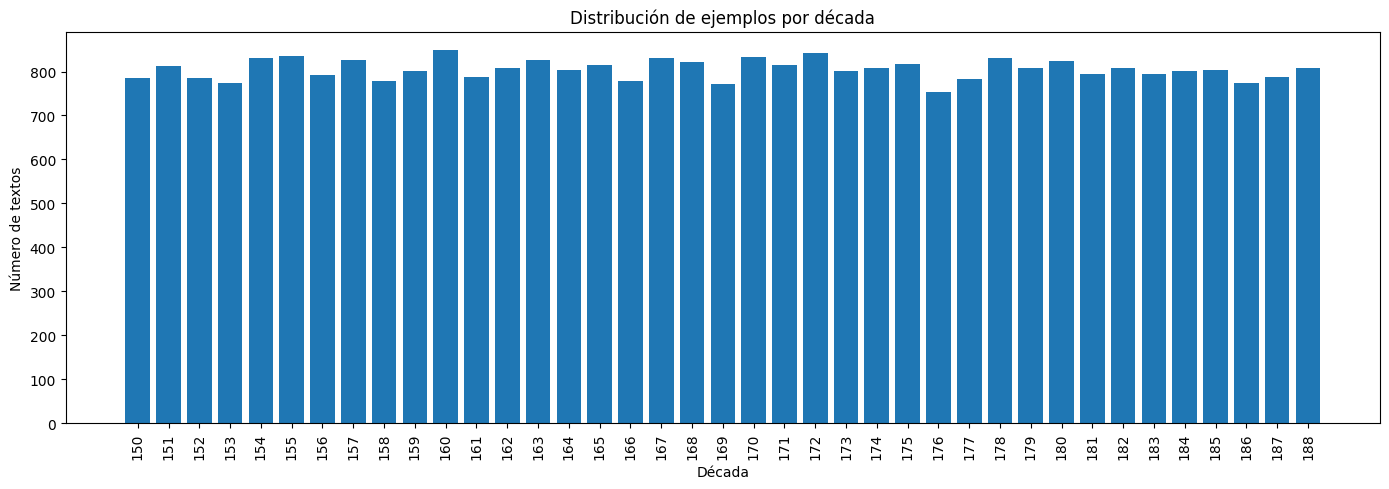

Mínimo por década: 754
Máximo por década: 848
Promedio por década: 805.2051282051282


In [5]:
# =========================
# 5. Histograma / distribución de décadas
# =========================

decade_counts = df["decade"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(decade_counts.index.astype(str), decade_counts.values)
plt.title("Distribución de ejemplos por década")
plt.xlabel("Década")
plt.ylabel("Número de textos")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Mínimo por década:", decade_counts.min())
print("Máximo por década:", decade_counts.max())
print("Promedio por década:", decade_counts.mean())

In [6]:
# =========================
# 6. Longitud de los textos
# =========================

df["text"] = df["text"].astype(str)

df["n_chars"] = df["text"].apply(len)
df["n_words"] = df["text"].apply(lambda x: len(x.split()))

print(df[["n_chars", "n_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

            n_chars      n_words
count  31403.000000  31403.00000
mean     520.568290     82.28319
std      530.947792     82.37419
min      120.000000      3.00000
25%      182.000000     30.00000
50%      315.000000     50.00000
75%      643.000000    102.00000
90%     1198.000000    189.00000
95%     1627.000000    255.00000
max     7418.000000   1146.00000


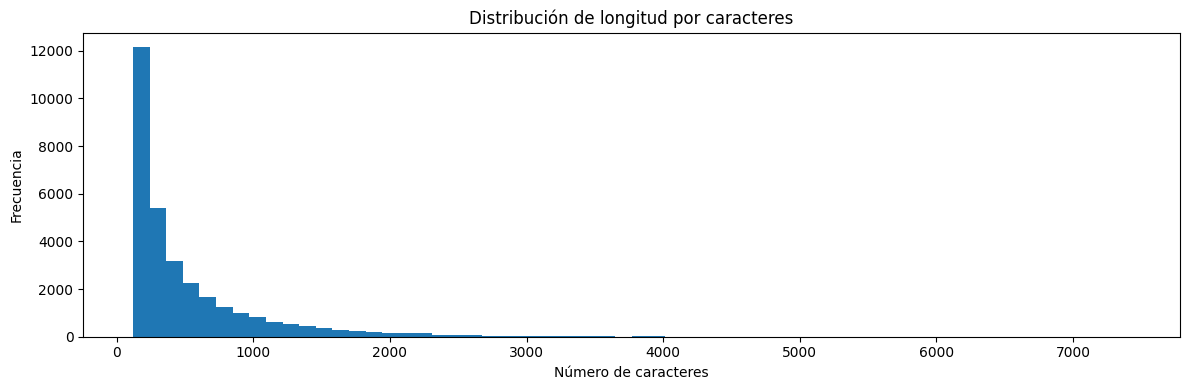

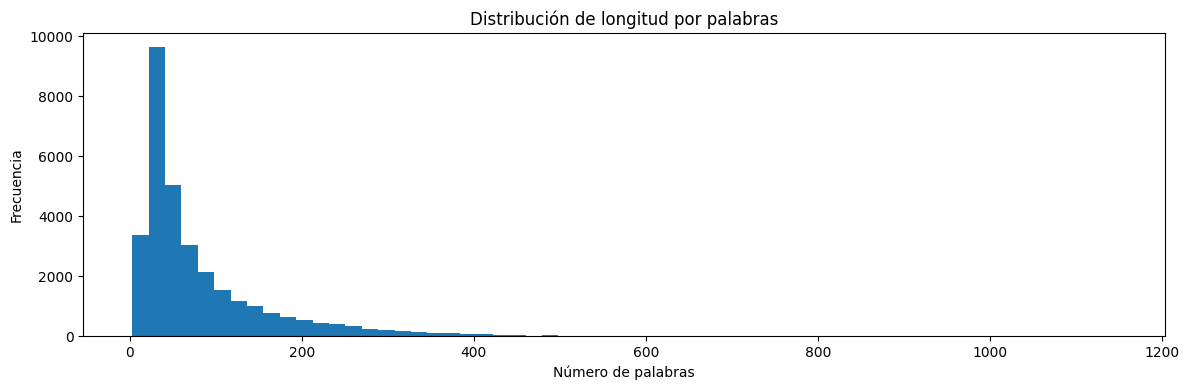

In [7]:
# =========================
# 7. Histogramas de longitud
# =========================

plt.figure(figsize=(12, 4))
plt.hist(df["n_chars"], bins=60)
plt.title("Distribución de longitud por caracteres")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.hist(df["n_words"], bins=60)
plt.title("Distribución de longitud por palabras")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

,n_chars,n_words
decade,,
150,280.938931,45.681934
151,853.219212,115.688424
152,385.298089,55.718471
153,678.868387,96.704516
154,674.649398,100.200000


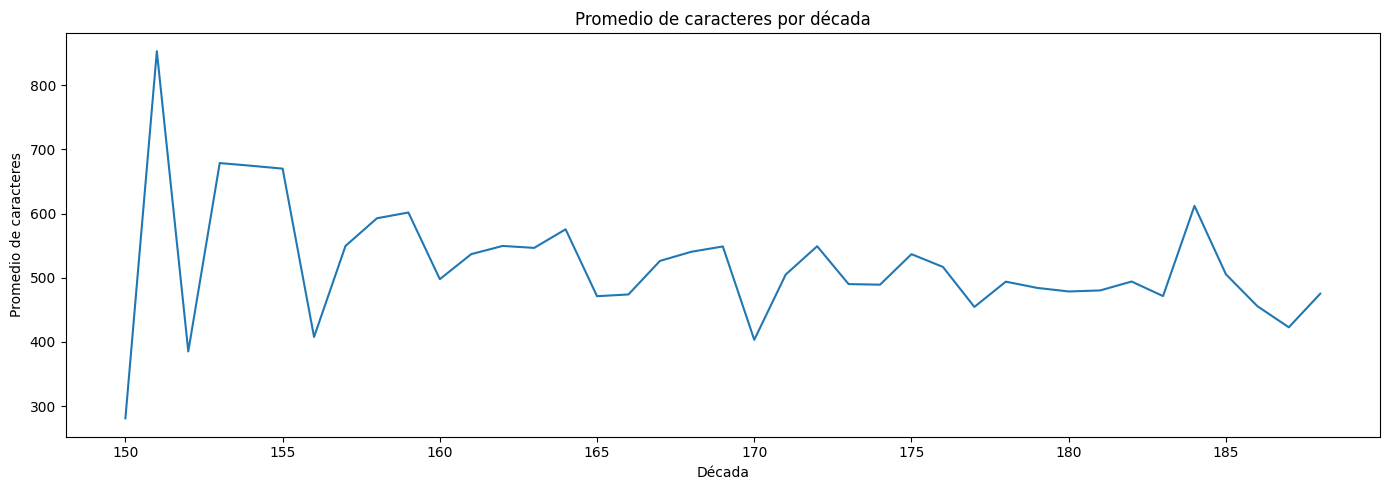

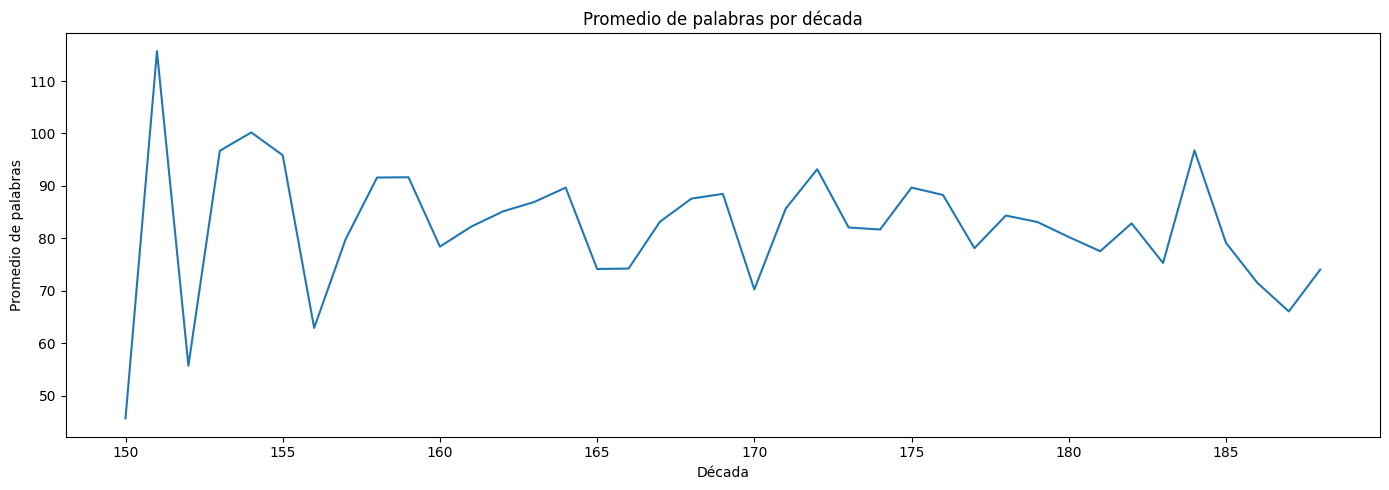

In [8]:
# =========================
# 8. Longitud promedio por década
# =========================

length_by_decade = (
    df.groupby("decade")[["n_chars", "n_words"]]
    .mean()
    .sort_index()
)

display(length_by_decade.head())

plt.figure(figsize=(14, 5))
plt.plot(length_by_decade.index, length_by_decade["n_chars"])
plt.title("Promedio de caracteres por década")
plt.xlabel("Década")
plt.ylabel("Promedio de caracteres")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(length_by_decade.index, length_by_decade["n_words"])
plt.title("Promedio de palabras por década")
plt.xlabel("Década")
plt.ylabel("Promedio de palabras")
plt.tight_layout()
plt.show()

In [9]:
# =========================
# Revisión de duplicados antes de limpiar
# =========================

print("Filas totales:", len(df))
print("Duplicados exactos de fila completa:", df.duplicated().sum())
print("Duplicados exactos por texto:", df.duplicated(subset=["text"]).sum())
print("Duplicados exactos por (text, decade):", df.duplicated(subset=["text", "decade"]).sum())

Filas totales: 31403
Duplicados exactos de fila completa: 34
Duplicados exactos por texto: 51
Duplicados exactos por (text, decade): 34


In [10]:
# =========================
# Ver ejemplos de textos duplicados
# =========================

duplicated_texts = df[df.duplicated(subset=["text"], keep=False)].copy()

print("Número de filas involucradas en textos duplicados:", len(duplicated_texts))
display(duplicated_texts.sort_values("text").head(20))

Número de filas involucradas en textos duplicados: 95


,text,decade,n_chars,n_words
8630,"\nEarly European Books, Copyright© 201 1 ...",155,141,18
28761,"\nEarly European Books, Copyright© 201 1 ...",155,141,18
24120,"\nEarly European Books, Copyright© 201 1 ...",155,141,18
250,"\nEarly European Books, Copyright© 201 1 ...",158,138,18
18673,"\nEarly European Books, Copyright© 201 1 ...",158,138,18
20681,"\nEarly European Books, Copyright© 201 1 ...",158,138,18
27603,"\nEarly Europeon Books, Copyright© 201 1 ...",158,138,18
11557,"\nEarly Europeon Books, Copyright© 201 1 ...",158,138,18
23605,"\nEarly European Books, Copyright O 2011 ProQu...",152,135,19
18136,"\nEarly European Books, Copyright O 2011 ProQu...",152,135,19


In [11]:
# =========================
# Revisar si un mismo texto aparece con más de una década
# =========================

text_with_multiple_decades = (
    df.groupby("text")["decade"]
      .nunique()
      .reset_index(name="n_unique_decades")
)

conflicting_texts = text_with_multiple_decades[text_with_multiple_decades["n_unique_decades"] > 1]

print("Número de textos que aparecen con más de una década:", len(conflicting_texts))
display(conflicting_texts.head(20))

Número de textos que aparecen con más de una década: 12


,text,n_unique_decades
8171,+ Haga un uso exclusivamente no comercial de e...,2
8173,"+ Keep it legal Whatever your use, remember th...",3
8175,"+ Maintain attribution The Google ""watermark"" ...",2
8178,+ Make non-commercial use of the files We desi...,2
8180,+ Manténgase siempre dentro de la legalidad Se...,3
16151,Google is proud to partner with libraries to d...,2
16249,Ha sobrevivido tantos años como para que los d...,3
16775,It has survived long enough for the copyright ...,4
18194,"Marks, notations and other maiginalia present ...",2
18195,"Marks, notations and other marginalia present ...",2


In [12]:
# =========================
# Mostrar ejemplos conflictivos completos
# =========================

if len(conflicting_texts) > 0:
    conflicting_examples = df[df["text"].isin(conflicting_texts["text"])].sort_values("text")
    display(conflicting_examples.head(30))
else:
    print("No hay textos repetidos con décadas distintas.")

,text,decade,n_chars,n_words
11320,+ Haga un uso exclusivamente no comercial de e...,183,225,37
6834,+ Haga un uso exclusivamente no comercial de e...,181,225,37
30705,"+ Keep it legal Whatever your use, remember th...",186,636,115
16203,"+ Keep it legal Whatever your use, remember th...",180,636,115
3382,"+ Keep it legal Whatever your use, remember th...",175,636,115
8174,"+ Maintain attribution The Google ""watermark"" ...",179,218,35
5840,"+ Maintain attribution The Google ""watermark"" ...",157,218,35
8989,+ Make non-commercial use of the files We desi...,162,174,28
5366,+ Make non-commercial use of the files We desi...,188,174,28
13141,+ Manténgase siempre dentro de la legalidad Se...,155,729,130


In [13]:
# =========================
# Resumen útil de duplicados
# =========================

n_total = len(df)
n_dup_rows = df.duplicated().sum()
n_dup_text = df.duplicated(subset=["text"]).sum()
n_dup_text_decade = df.duplicated(subset=["text", "decade"]).sum()

print(f"Total de filas: {n_total}")
print(f"Duplicados exactos de fila completa: {n_dup_rows} ({n_dup_rows/n_total:.2%})")
print(f"Duplicados por texto: {n_dup_text} ({n_dup_text/n_total:.2%})")
print(f"Duplicados por texto+decade: {n_dup_text_decade} ({n_dup_text_decade/n_total:.2%})")

Total de filas: 31403
Duplicados exactos de fila completa: 34 (0.11%)
Duplicados por texto: 51 (0.16%)
Duplicados por texto+decade: 34 (0.11%)


In [14]:
text_with_multiple_decades = (
    df.groupby("text")["decade"]
      .nunique()
      .reset_index(name="n_unique_decades")
)

conflicting_texts = text_with_multiple_decades[text_with_multiple_decades["n_unique_decades"] > 1]

print("Número de textos que aparecen con más de una década:", len(conflicting_texts))

if len(conflicting_texts) > 0:
    conflicting_examples = df[df["text"].isin(conflicting_texts["text"])].sort_values(["text", "decade"])
    display(conflicting_examples.head(50))

Número de textos que aparecen con más de una década: 12


,text,decade,n_chars,n_words
6834,+ Haga un uso exclusivamente no comercial de e...,181,225,37
11320,+ Haga un uso exclusivamente no comercial de e...,183,225,37
3382,"+ Keep it legal Whatever your use, remember th...",175,636,115
16203,"+ Keep it legal Whatever your use, remember th...",180,636,115
30705,"+ Keep it legal Whatever your use, remember th...",186,636,115
5840,"+ Maintain attribution The Google ""watermark"" ...",157,218,35
8174,"+ Maintain attribution The Google ""watermark"" ...",179,218,35
8989,+ Make non-commercial use of the files We desi...,162,174,28
5366,+ Make non-commercial use of the files We desi...,188,174,28
13141,+ Manténgase siempre dentro de la legalidad Se...,155,729,130


In [15]:
# =========================
# 9. Inspección manual de ejemplos
# =========================

pd.set_option("display.max_colwidth", 500)

display(df.sample(5, random_state=42)[["decade", "text"]])

,decade,text
11265,183,"— Levanta, hija mia, repuso el supuesto fraile: ¿quién \neres, dime, que andas sola por estos despoblados?"
27517,184,"13. Item mando que en la dicha mi villa de Co- \nyoacan se edifique y haga un colegio para estudiantes \nque estudien teología y derecho canónico para qae ha- \nya (*""] personas doctas en la Nueva España que rijan las"
5925,175,"mente. La fegunda , de lo que oyeron dezir. La ter- \ncera , de lo que creen fobre aquel fecho de que les \npreguntan, fi es afsi , o non. Pero li el Rey ouicre de \nt'azcr la pefquifa , puédeles tomar jura, en efta guifa, \níin libro i tomando las fus m^ios dellos entre las Pu- \nyas , c conjurándolos por tales cofas conro las que \ndiximos en cita ley , demas por el feñorio que ha fo- \nbre ellos , e ib aquella pena que el en..."
3776,154,"dades De Dentro a fuera, y pozqelfolre^ Bueiroís Deía l?^enia Del l?ueuo/ q Da ti \nfuelue mucl?as parres De Ijuinedadfupa- so ínáreníiníéto al cuerpo/quáto día pe^ \nfl:iaDela cera/que la l^ajenparefcer aína fa.iSs De notar q pierden !a blancura lo?"
29573,161,"ESPERIENCI A.Lat.experien \ntia,es el conocimiento y noticia de algu \nna cofa q fe ha fabido por vfo, prouádo \nla, y. experimentándola, fin enfeñamien \nto de otro, defalir cierta en muchospar \nticulares,refultael arte, q es de vniuer- \nfales.Mart. lib.i."


In [16]:
# =========================
# 10. Limpieza conservadora
# =========================

def minimal_clean_text(text):
    text = str(text)
    
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", text)

    # Normaliza saltos de línea y tabs a espacios
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    
    # Reduce múltiples espacios a uno solo
    text = re.sub(r"\s+", " ", text).strip()
    
    # Pasa a minúsculas
    text = text.lower()
    
    return text

df["text_clean"] = df["text"].apply(minimal_clean_text)

df = df.dropna(subset=["text_clean", "decade"]).copy()

display(df[["text", "text_clean"]].sample(5, random_state=42))

,text,text_clean
11265,"— Levanta, hija mia, repuso el supuesto fraile: ¿quién \neres, dime, que andas sola por estos despoblados?","— levanta, hija mia, repuso el supuesto fraile: ¿quién eres, dime, que andas sola por estos despoblados?"
27517,"13. Item mando que en la dicha mi villa de Co- \nyoacan se edifique y haga un colegio para estudiantes \nque estudien teología y derecho canónico para qae ha- \nya (*""] personas doctas en la Nueva España que rijan las","13. item mando que en la dicha mi villa de co- yoacan se edifique y haga un colegio para estudiantes que estudien teología y derecho canónico para qae ha- ya (*""] personas doctas en la nueva españa que rijan las"
5925,"mente. La fegunda , de lo que oyeron dezir. La ter- \ncera , de lo que creen fobre aquel fecho de que les \npreguntan, fi es afsi , o non. Pero li el Rey ouicre de \nt'azcr la pefquifa , puédeles tomar jura, en efta guifa, \níin libro i tomando las fus m^ios dellos entre las Pu- \nyas , c conjurándolos por tales cofas conro las que \ndiximos en cita ley , demas por el feñorio que ha fo- \nbre ellos , e ib aquella pena que el en...","mente. la fegunda , de lo que oyeron dezir. la ter- cera , de lo que creen fobre aquel fecho de que les preguntan, fi es afsi , o non. pero li el rey ouicre de t'azcr la pefquifa , puédeles tomar jura, en efta guifa, íin libro i tomando las fus m^ios dellos entre las pu- yas , c conjurándolos por tales cofas conro las que diximos en cita ley , demas por el feñorio que ha fo- bre ellos , e ib aquella pena que el entendiere que mereícen , icgund el fecho fuere , íi le negatten la verdad."
3776,"dades De Dentro a fuera, y pozqelfolre^ Bueiroís Deía l?^enia Del l?ueuo/ q Da ti \nfuelue mucl?as parres De Ijuinedadfupa- so ínáreníiníéto al cuerpo/quáto día pe^ \nfl:iaDela cera/que la l^ajenparefcer aína fa.iSs De notar q pierden !a blancura lo?","dades de dentro a fuera, y pozqelfolre^ bueiroís deía l?^enia del l?ueuo/ q da ti fuelue mucl?as parres de ijuinedadfupa- so ínáreníiníéto al cuerpo/quáto día pe^ fl:iadela cera/que la l^ajenparefcer aína fa.iss de notar q pierden !a blancura lo?"
29573,"ESPERIENCI A.Lat.experien \ntia,es el conocimiento y noticia de algu \nna cofa q fe ha fabido por vfo, prouádo \nla, y. experimentándola, fin enfeñamien \nto de otro, defalir cierta en muchospar \nticulares,refultael arte, q es de vniuer- \nfales.Mart. lib.i.","esperienci a.lat.experien tia,es el conocimiento y noticia de algu na cofa q fe ha fabido por vfo, prouádo la, y. experimentándola, fin enfeñamien to de otro, defalir cierta en muchospar ticulares,refultael arte, q es de vniuer- fales.mart. lib.i."


In [17]:
# =========================
# 11. Validación rápida de la limpieza
# =========================

print("Nulos en text_clean:", df["text_clean"].isnull().sum())
print("Textos vacíos tras limpieza:", (df["text_clean"].str.len() == 0).sum())

display(df[["decade", "text_clean"]].head())

Nulos en text_clean: 0
Textos vacíos tras limpieza: 0


,decade,text_clean
0,164,"honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft.s 2.donde * llama ocloso cingv- y 19"
1,182,"gone. sus amigos , sus clientes, todo cuanto le rodea le prueban que es hom- bre de mucha importancia. si ve que al- gunos hombre» plebeyos á fuerza de ser- vicios y de hazañas se elevan de la cla- se en que nacieron, se consuela dicien- do: puús para lles^nr á la '-hxe en ijue estoy ^ todavia necesita su familia de mu- chos años de antigüedad."
2,157,"prefosen quemanera,e per qualesfolpechas deuan feratormentados, e ante quien,e quie preguntasles deuan hazer mientras los tormentarf, vecla.lstitopuzo"
3,163,"caistro el m a y o r a i .] del apellido de cañroíe valió don luis enefta. metáfora, para el nombre que fupo ne de caiftro. mayoral fe llama entre los ganaderos el que tiene el primer lugar, y a quien efián fujetos los de¬ mas, y defia mayoría tomó el nombte."
4,166,"los que panden macho ; y otros en la fu ña abundan¬ cia , íiempre viuen como mendigos. la lana aun en el edito fagrado compite con el sol luzimieutos,' pues a los dos los llama moy fes aftros de claridad fupsnor , no dando a otra ellreliaefta precrogatiua; viclt dsus da ) laminaria magna. si fe atiende a las dcmonílraciones de los ma temáticos,!* luna tolo es mayor quemercurio,y me¬ nor que todos los demás aftrossdífpues de eflb,por <que en la apariencia viáble, es mas oftentofa a los ojos d..."


In [18]:
# =========================
# 13. Separación train/validation
# =========================

X = df["text_clean"]
y = df["decade"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamaño train:", X_train.shape[0])
print("Tamaño validation:", X_val.shape[0])
print("Clases en train:", y_train.nunique())
print("Clases en validation:", y_val.nunique())

Tamaño train: 25122
Tamaño validation: 6281
Clases en train: 39
Clases en validation: 39


In [19]:
# =========================
# 14. Pipeline baseline
# TF-IDF de caracteres (2,5) + Regresión Logística
# =========================

baseline_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            lowercase=False,
            min_df=5,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LogisticRegression(
            C=2,
            max_iter=2000,
            n_jobs=-1,
            random_state=42
        )
    )
])

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",False
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [20]:
# =========================
# 15. Entrenamiento del baseline
# =========================

baseline_pipeline.fit(X_train, y_train)

c:\Users\jacsi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",False
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [21]:
# =========================
# 16. Predicción en validation
# =========================

y_val_pred = baseline_pipeline.predict(X_val)

print("Accuracy en validation:", accuracy_score(y_val, y_val_pred))

Accuracy en validation: 0.2846680464894125


In [22]:
# =========================
# 17. Reporte de clasificación
# =========================

report = classification_report(y_val, y_val_pred, digits=4)
print(report)

              precision    recall  f1-score   support

         150     0.7438    0.7580    0.7508       157
         151     0.4265    0.7346    0.5397       162
         152     0.6304    0.5541    0.5898       157
         153     0.5851    0.7097    0.6414       155
         154     0.5000    0.5964    0.5440       166
         155     0.3759    0.3174    0.3442       167
         156     0.3529    0.4177    0.3826       158
         157     0.2938    0.3735    0.3289       166
         158     0.2768    0.3141    0.2943       156
         159     0.2397    0.3625    0.2886       160
         160     0.1603    0.1235    0.1395       170
         161     0.1416    0.1019    0.1185       157
         162     0.2051    0.1975    0.2013       162
         163     0.1800    0.1627    0.1709       166
         164     0.2109    0.1677    0.1869       161
         165     0.0977    0.0798    0.0878       163
         166     0.1096    0.0513    0.0699       156
         167     0.2467    

In [23]:
# =========================
# 18. Accuracy balanceado
# =========================

from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
print("Balanced accuracy en validation:", balanced_acc)

Balanced accuracy en validation: 0.28475401083528284


Error absoluto promedio en décadas: 3.6319057474924374
Mediana del error absoluto: 2.0


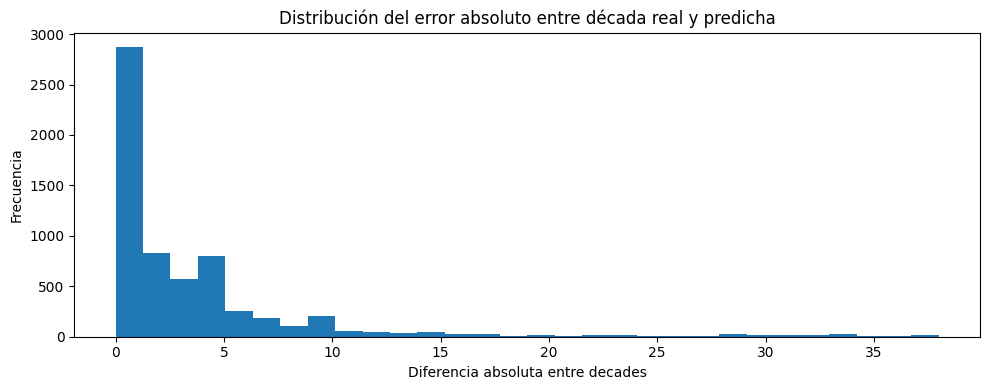

In [24]:
# =========================
# 19. Distancia entre década real y predicha
# =========================

error_distance = np.abs(y_val_pred - y_val)

print("Error absoluto promedio en décadas:", error_distance.mean())
print("Mediana del error absoluto:", np.median(error_distance))

plt.figure(figsize=(10, 4))
plt.hist(error_distance, bins=30)
plt.title("Distribución del error absoluto entre década real y predicha")
plt.xlabel("Diferencia absoluta entre decades")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

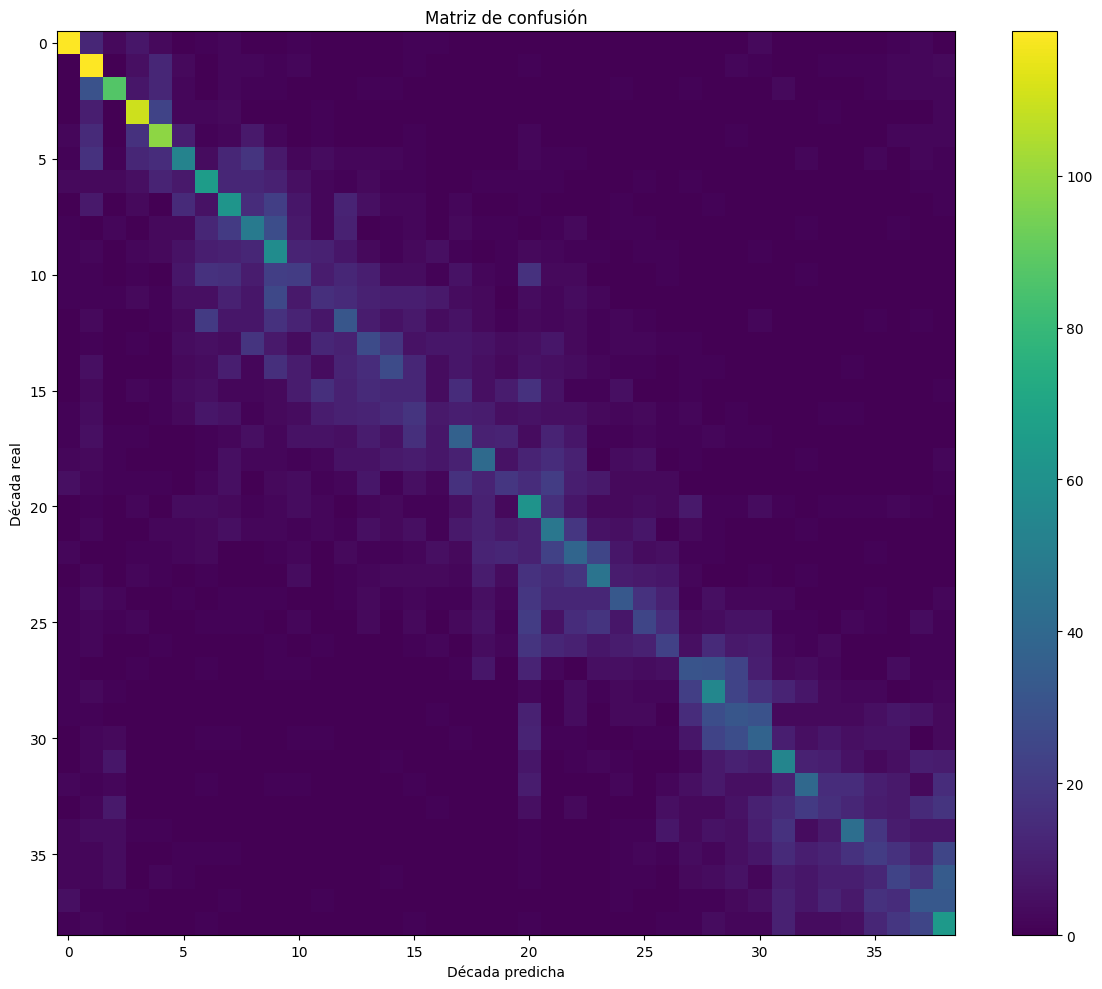

In [25]:
# =========================
# 20. Matriz de confusión
# =========================

cm = confusion_matrix(y_val, y_val_pred, labels=sorted(y.unique()))

plt.figure(figsize=(12, 10))
plt.imshow(cm, aspect="auto")
plt.title("Matriz de confusión")
plt.xlabel("Década predicha")
plt.ylabel("Década real")
plt.colorbar()
plt.tight_layout()
plt.show()

In [26]:
# =========================
# 21. Resumen del baseline
# =========================

baseline_results = {
    "model": "tfidf_char_3_5_logreg",
    "accuracy": accuracy_score(y_val, y_val_pred),
    "balanced_accuracy": balanced_accuracy_score(y_val, y_val_pred),
    "mean_absolute_decade_error": error_distance.mean(),
    "median_absolute_decade_error": np.median(error_distance)
}

baseline_results

{'model': 'tfidf_char_3_5_logreg',
 'accuracy': 0.2846680464894125,
 'balanced_accuracy': 0.28475401083528284,
 'mean_absolute_decade_error': np.float64(3.6319057474924374),
 'median_absolute_decade_error': np.float64(2.0)}

In [27]:
# =========================
# 22. Guardar el baseline entrenado
# =========================

import joblib

joblib.dump(baseline_pipeline, "baseline_tfidf_char_3_5_logreg.joblib")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [28]:
# 1. Cargar modelo
modelo = joblib.load("baseline_tfidf_char_3_5_logreg.joblib")

# 2. Cargar eval
eval_df = pd.read_csv("eval.csv")

eval_df["text_clean"] = eval_df["text"].apply(minimal_clean_text)

# 3. Predecir décadas
predicciones = modelo.predict(eval_df["text_clean"])

# 4. Crear archivo en formato requerido
submission = pd.DataFrame({
    "id": eval_df["id"],
    "answer": predicciones
})

# 5. Guardar
submission.to_csv("predictions_eval.csv", index=False)

print("Archivo listo: predictions_eval.csv")

Archivo listo: predictions_eval.csv


In [29]:
print(predicciones.shape)

(3490,)
